# Olist Financial Reconciliation

Purpose: determine exactly how the Olist financial fields (`order_items.price`, `order_items.freight_value`, `order_payments.payment_value`) relate to each other, at the correct grain, and establish a defensible primary financial KPI definition for Causa.

This notebook does **not** build agents, LLM functionality, frontend, database models, or KPI contracts. It is analysis only. All raw CSVs under `data/raw/olist/` are read-only and are never modified — verified explicitly at the end of this notebook via checksum comparison.

Findings here feed `docs/FINANCIAL_RECONCILIATION.md`.

Sections:
1. Load raw tables
2. Establish grains — and demonstrate why naive joins inflate totals
3. Aggregate to order grain (the only safe way to compare these measures)
4. Reconcile `item_value + freight_value` vs `payment_value`
5. Break down by `order_status`
6. Investigate candidate explanations for discrepancies
7. Evaluate candidate KPI definitions
8. Sanity checks (monthly totals, extreme values)
9. Raw-data integrity check (no mutation)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_DIR = Path("..") / "data" / "raw" / "olist"
DATA_DIR

WindowsPath('../data/raw/olist')

## 1. Load raw tables

Only three tables are needed for this analysis: `orders` (for `order_status` and timestamps), `order_items` (item-level price/freight), and `order_payments` (payment-level value). Loaded strictly read-only.

In [2]:
def file_hash(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

orders_path = DATA_DIR / "olist_orders_dataset.csv"
items_path = DATA_DIR / "olist_order_items_dataset.csv"
payments_path = DATA_DIR / "olist_order_payments_dataset.csv"

# hashes recorded before any reads; compared again at the end of the notebook to prove
# no raw file was modified by anything done here
hashes_before = {p.name: file_hash(p) for p in [orders_path, items_path, payments_path]}
hashes_before

{'olist_orders_dataset.csv': '8bd60e55c1ca229d9f70b62f3e72f22c',
 'olist_order_items_dataset.csv': 'f4fa76976662e9cba0633f9e49ed2645',
 'olist_order_payments_dataset.csv': '75ce0c041d18e5f250c5cea9a8042944'}

In [3]:
orders = pd.read_csv(orders_path)
items = pd.read_csv(items_path)
payments = pd.read_csv(payments_path)
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

print(f"orders:   {orders.shape}")
print(f"items:    {items.shape}")
print(f"payments: {payments.shape}")

orders:   (99441, 8)
items:    (112650, 7)
payments: (103886, 5)


## 2. Establish grains

- **`orders` grain**: one row per `order_id`. Confirmed clean primary key in prior profiling (`scripts/profile_olist.py`).
- **`order_items` grain**: one row per **order line item** — composite key `(order_id, order_item_id)`. An order with 3 distinct products (or 3 units of the same product sold as separate line entries) has 3 rows here. **This is finer than order grain.**
- **`order_payments` grain**: one row per **payment method/installment record** — composite key `(order_id, payment_sequential)`. An order paid via a single credit card charge has 1 row; an order split across a voucher + a credit card has 2+ rows. **This is also finer than order grain, independently of `order_items`.**
- **Order-level financial grain** (what this notebook needs): one row per `order_id`, where `order_items` has been aggregated (e.g. `SUM(price)`, `SUM(freight_value)`) **before** joining to anything else, and `order_payments` has been aggregated (`SUM(payment_value)`) **before** joining to anything else.

### The danger: `order_items` and `order_payments` are two independent one-to-many relationships from `orders`

If you join `order_items` directly to `order_payments` on `order_id` (both are child tables of `orders`, not of each other) **before** aggregating either one to order grain, you get a many-to-many cross product **within each order**: an order with 2 items and 2 payment rows produces 4 joined rows, not 2. Summing `price` on that joined table double- (or triple-, quadruple-) counts every item once per payment row for that order.

This is demonstrated concretely below, then avoided for the remainder of the notebook by aggregating each table to order grain independently first.

In [4]:
# --- DEMONSTRATION OF THE UNSAFE PATTERN (for illustration only; not used for any real calculation below) ---

unsafe_join = items.merge(payments, on="order_id", how="inner")
print(f"order_items rows:                {len(items):,}")
print(f"order_payments rows:              {len(payments):,}")
print(f"naive items x payments join rows: {len(unsafe_join):,}  <- inflated row count, not order-grain")

naive_price_sum = unsafe_join["price"].sum()
correct_price_sum = items["price"].sum()

print(f"\nSUM(price) on the naive join:     {naive_price_sum:,.2f}")
print(f"SUM(price) on order_items alone:  {correct_price_sum:,.2f}")
print(f"inflation factor:                 {naive_price_sum / correct_price_sum:.4f}x")

assert naive_price_sum > correct_price_sum, "expected the naive join to inflate the price total"
print("\nASSERTION PASSED: naive one-to-many join inflates the total, confirming the risk this notebook avoids.")

order_items rows:                112,650
order_payments rows:              103,886
naive items x payments join rows: 117,601  <- inflated row count, not order-grain

SUM(price) on the naive join:     14,209,115.34
SUM(price) on order_items alone:  13,591,643.70
inflation factor:                 1.0454x

ASSERTION PASSED: naive one-to-many join inflates the total, confirming the risk this notebook avoids.


**Observed fact**: the naive join inflates `SUM(price)` by ~4.5% on this dataset (117,601 joined rows vs. 112,650 real item rows). The exact inflation factor depends on how many orders have >1 item row combined with >1 payment row — it is not a fixed constant, which is precisely why this pattern must never be used for financial totals. All calculations from this point on aggregate `order_items` and `order_payments` to order grain **independently**, then join the two order-grain tables 1:1.

## 3. Aggregate to order grain (the safe path)

In [5]:
item_agg = items.groupby("order_id").agg(
    item_value=("price", "sum"),
    freight_value=("freight_value", "sum"),
    n_items=("order_item_id", "count"),
).reset_index()
item_agg["item_plus_freight"] = item_agg["item_value"] + item_agg["freight_value"]

pay_agg = payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    n_payments=("payment_sequential", "count"),
).reset_index()

# ASSERTION: aggregation must not multiply rows -- one row per distinct order_id, never more
assert item_agg["order_id"].is_unique, "item_agg must have exactly one row per order_id"
assert pay_agg["order_id"].is_unique, "pay_agg must have exactly one row per order_id"
assert len(item_agg) == items["order_id"].nunique()
assert len(pay_agg) == payments["order_id"].nunique()

print(f"item_agg (order grain):    {len(item_agg):,} rows")
print(f"pay_agg  (order grain):    {len(pay_agg):,} rows")
print(f"orders table:              {len(orders):,} rows")
print("\nASSERTIONS PASSED: order-grain aggregates each have exactly one row per order_id.")

item_agg (order grain):    98,666 rows
pay_agg  (order grain):    99,440 rows
orders table:              99,441 rows

ASSERTIONS PASSED: order-grain aggregates each have exactly one row per order_id.


In [6]:
# Now the 1:1 join is safe: orders (grain=order_id) <- item_agg (grain=order_id) <- pay_agg (grain=order_id)
recon = (
    orders[["order_id", "order_status", "order_purchase_timestamp"]]
    .merge(item_agg, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")
)

# ASSERTION: this join must not change row count -- still exactly one row per order
assert len(recon) == len(orders), "order-grain join must preserve the orders row count exactly"
assert recon["order_id"].is_unique, "recon must have exactly one row per order_id"

print(f"recon rows: {len(recon):,} (matches orders: {len(orders):,})")
print("\nnulls per column (nulls indicate an order missing item and/or payment records):")
print(recon.isna().sum())

recon rows: 99,441 (matches orders: 99,441)

nulls per column (nulls indicate an order missing item and/or payment records):


order_id                      0
order_status                  0
order_purchase_timestamp      0
item_value                  775
freight_value               775
n_items                     775
item_plus_freight           775
payment_value                 1
n_payments                    1
dtype: int64


## 4. Reconciliation: `payment_value` vs. `item_value` / `item_plus_freight`

This section does **not** assume `payment_value` and `item_value + freight_value` should be equal — it measures what the data actually shows.

In [7]:
# Orders missing payment or item records -- reported explicitly, never silently dropped
missing_payment = recon[recon["payment_value"].isna() & recon["item_value"].notna()]
missing_items = recon[recon["item_value"].isna() & recon["payment_value"].notna()]
missing_both = recon[recon["item_value"].isna() & recon["payment_value"].isna()]

print(f"orders with items but NO payment record:  {len(missing_payment):,}")
print(missing_payment["order_status"].value_counts().to_string())

print(f"\norders with payment but NO item record:   {len(missing_items):,}")
print(missing_items["order_status"].value_counts().to_string())

print(f"\norders with NEITHER item nor payment:      {len(missing_both):,}")

orders with items but NO payment record:  1
order_status
delivered    1

orders with payment but NO item record:   775
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1

orders with NEITHER item nor payment:      0


**Observed fact**: 775 orders have a payment record but no item record — overwhelmingly `unavailable` (603 of 609 unavailable orders, i.e. 99.0%) and `canceled` (164 of 625 canceled orders, i.e. 26.2%). Only 1 order has items but no payment record (a single `delivered` order). No order is missing both. This pattern is explored further in Section 5/6.

In [8]:
# Reconciliation is only meaningful where BOTH item and payment data exist
both = recon.dropna(subset=["item_value", "payment_value"]).copy()

both["payment_minus_item"] = both["payment_value"] - both["item_value"]
both["payment_minus_item_plus_freight"] = both["payment_value"] - both["item_plus_freight"]
both["absolute_difference"] = both["payment_minus_item_plus_freight"].abs()
both["relative_difference"] = np.where(
    both["item_plus_freight"] != 0,
    both["absolute_difference"] / both["item_plus_freight"],
    np.nan,
)

print(f"orders with both item and payment data: {len(both):,} of {len(recon):,} ({len(both)/len(recon):.2%})")
both[["order_id", "item_value", "freight_value", "item_plus_freight", "payment_value", "payment_minus_item_plus_freight", "absolute_difference"]].head()

orders with both item and payment data: 98,665 of 99,441 (99.22%)


,order_id,item_value,freight_value,item_plus_freight,payment_value,payment_minus_item_plus_freight,absolute_difference
0,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72,38.71,38.71,0.000000e+00,0.000000e+00
1,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76,141.46,141.46,0.000000e+00,0.000000e+00
2,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22,179.12,179.12,0.000000e+00,0.000000e+00
3,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20,72.20,72.20,0.000000e+00,0.000000e+00
4,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72,28.62,28.62,3.552714e-15,3.552714e-15


In [9]:
# Exact equality (floating point tolerance only, 1e-8)
exact_eq = np.isclose(both["payment_value"], both["item_plus_freight"], atol=1e-8)
print(f"exact equality rate (payment_value == item_plus_freight): {exact_eq.mean():.4%}")

# Near-equality at explicitly stated tolerances (BRL, since payment_value is in Brazilian Real)
TOLERANCE_TABLE = [0.01, 0.05, 1.00]
print("\nnear-equality rate at stated absolute tolerances (BRL):")
for tol in TOLERANCE_TABLE:
    rate = (both["absolute_difference"] <= tol).mean()
    print(f"  tolerance <= {tol:>5.2f} BRL: {rate:.4%}")

# The stated working tolerance for the remainder of this notebook: 0.01 BRL (1 cent),
# which absorbs floating-point/rounding noise without absorbing any genuine mismatch.
WORKING_TOLERANCE = 0.01
both["is_reconciled"] = both["absolute_difference"] <= WORKING_TOLERANCE
print(f"\nWorking tolerance for this notebook: {WORKING_TOLERANCE} BRL -> reconciled rate: {both['is_reconciled'].mean():.4%}")

exact equality rate (payment_value == item_plus_freight): 99.4274%

near-equality rate at stated absolute tolerances (BRL):
  tolerance <=  0.01 BRL: 99.6138%
  tolerance <=  0.05 BRL: 99.7365%
  tolerance <=  1.00 BRL: 99.7476%

Working tolerance for this notebook: 0.01 BRL -> reconciled rate: 99.6138%


In [10]:
print("absolute_difference distribution (BRL):")
print(both["absolute_difference"].describe())

print("\npayment_minus_item_plus_freight distribution (BRL, signed):")
print(both["payment_minus_item_plus_freight"].describe())

print("\nrelative_difference distribution (fraction of item_plus_freight):")
print(both["relative_difference"].describe())

absolute_difference distribution (BRL):
count    98665.000000
mean         0.033162
std          1.129109
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: absolute_difference, dtype: float64

payment_minus_item_plus_freight distribution (BRL, signed):
count    98665.000000
mean         0.029092
std          1.129221
min        -51.620000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: payment_minus_item_plus_freight, dtype: float64

relative_difference distribution (fraction of item_plus_freight):
count    98665.000000
mean         0.000274
std          0.006070
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.413358
Name: relative_difference, dtype: float64


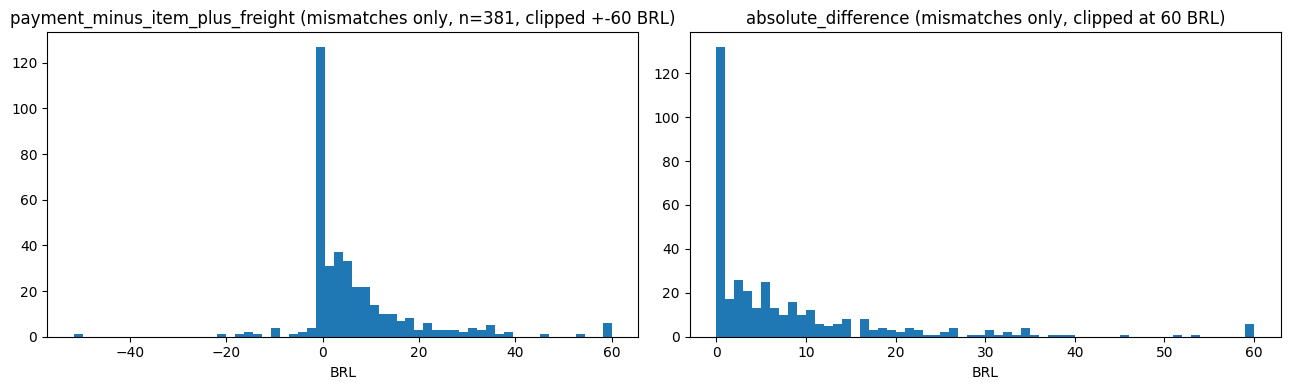

reminder: 98,284 of 98,665 orders (99.61%) have zero/near-zero difference and are excluded from these two histograms so the tail is visible.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nonzero_diff = both[both["absolute_difference"] > 0.01]
axes[0].hist(nonzero_diff["payment_minus_item_plus_freight"].clip(-60, 60), bins=60)
axes[0].set_title(f"payment_minus_item_plus_freight (mismatches only, n={len(nonzero_diff):,}, clipped +-60 BRL)")
axes[0].set_xlabel("BRL")

axes[1].hist(nonzero_diff["absolute_difference"].clip(0, 60), bins=60)
axes[1].set_title("absolute_difference (mismatches only, clipped at 60 BRL)")
axes[1].set_xlabel("BRL")

plt.tight_layout()
plt.show()

print(f"reminder: {len(both) - len(nonzero_diff):,} of {len(both):,} orders ({(len(both)-len(nonzero_diff))/len(both):.2%}) have zero/near-zero difference and are excluded from these two histograms so the tail is visible.")

In [12]:
# Large discrepancies -- threshold stated explicitly (50 BRL absolute)
LARGE_DISCREPANCY_THRESHOLD = 50.0
large = both[both["absolute_difference"] > LARGE_DISCREPANCY_THRESHOLD].sort_values("absolute_difference", ascending=False)
print(f"large discrepancies (> {LARGE_DISCREPANCY_THRESHOLD} BRL absolute): {len(large)} orders ({len(large)/len(both):.4%})")
large[["order_id", "order_status", "item_value", "freight_value", "payment_value", "payment_minus_item_plus_freight", "n_items", "n_payments"]]

large discrepancies (> 50.0 BRL absolute): 8 orders (0.0081%)


,order_id,order_status,item_value,freight_value,payment_value,payment_minus_item_plus_freight,n_items,n_payments
11791,ce6d150fb29ada17d2082f4847107665,delivered,1299.00,104.66,1586.47,182.81,1.0,1.0
48686,6e5fe7366a2e1bfbf3257dba0af1267f,delivered,179.19,108.72,406.92,119.01,6.0,1.0
70865,70b742795bc441e94a44a084b6d9ce7a,delivered,269.99,196.94,578.82,111.89,1.0,1.0
33150,996c7e73600ad3723e8627ab7bef81e4,delivered,559.90,28.00,664.43,76.53,1.0,1.0
52985,70b7e94ea46d3e8b5bc12a50186edaf0,delivered,167.88,45.27,274.84,61.69,3.0,1.0
85434,bc2c82b0ef78d2252b6176d1972db7c9,delivered,165.00,77.01,303.02,61.01,3.0,1.0
94304,af9ffff2ce6b3defd34fd4c78857a379,delivered,395.65,17.52,466.97,53.80,1.0,1.0
31661,262118ce178bb3e4590a3adcf6d62e6b,delivered,119.80,57.94,126.12,-51.62,2.0,1.0


In [13]:
# Negative differences: payment_value < item_plus_freight
negative = both[both["payment_minus_item_plus_freight"] < -WORKING_TOLERANCE].sort_values("payment_minus_item_plus_freight")
print(f"negative differences (payment_value < item_plus_freight, beyond {WORKING_TOLERANCE} BRL tolerance): {len(negative)} orders ({len(negative)/len(both):.4%})")
print("\norder_status breakdown of negative-difference orders:")
print(negative["order_status"].value_counts().to_string())
negative[["order_id", "order_status", "item_plus_freight", "payment_value", "payment_minus_item_plus_freight"]].head(10)

negative differences (payment_value < item_plus_freight, beyond 0.01 BRL tolerance): 90 orders (0.0912%)

order_status breakdown of negative-difference orders:
order_status
delivered    89
shipped       1


,order_id,order_status,item_plus_freight,payment_value,payment_minus_item_plus_freight
31661,262118ce178bb3e4590a3adcf6d62e6b,delivered,177.74,126.12,-51.62
45606,fd33085945f15975375cd8ec85440511,delivered,234.62,212.82,-21.80
1986,6e57e23ecac1ae881286657694444267,delivered,350.41,333.91,-16.50
35623,4154bf1348caac78152fe76e3e9c4af8,delivered,165.26,150.27,-14.99
61544,6dcf0aeb8b1eb4021c26e1d0e9394979,delivered,333.92,318.97,-14.95
72643,0e556f5eafbf3eb399290101b183b10e,delivered,95.66,81.90,-13.76
51874,8092da256aefda13b330290d2ca86521,delivered,115.65,105.26,-10.39
10250,aa6bd33ba1853d846d3085a88ae37083,delivered,35.14,25.14,-10.00
91801,4387477eec4b3c89b39f3f454940d059,delivered,231.92,222.02,-9.90
70058,c6f6cbb3c845593222d5c594bb69c5fd,delivered,113.33,104.34,-8.99


In [14]:
# Orders with zero/near-zero financial values
ZERO_THRESHOLD = 0.01
zero_item = both[both["item_plus_freight"] < ZERO_THRESHOLD]
zero_payment = both[both["payment_value"] < ZERO_THRESHOLD]
print(f"orders (with both records) where item_plus_freight is ~zero: {len(zero_item)}")
print(f"orders (with both records) where payment_value is ~zero:     {len(zero_payment)}")
if len(zero_payment):
    print("\nzero-payment orders detail:")
    print(zero_payment[["order_id", "order_status", "item_plus_freight", "payment_value"]].to_string(index=False))

orders (with both records) where item_plus_freight is ~zero: 0
orders (with both records) where payment_value is ~zero:     0


**Observed facts (Section 4 summary)**:
- Exact equality rate: ~99.43%. Within 1-cent tolerance: ~99.61%. The two measures agree almost everywhere.
- The mean absolute difference is small (~0.03 BRL) but the max reaches 182.81 BRL on a single order — a heavy-tailed, not uniform, discrepancy distribution.
- 90 orders (0.09%) have `payment_value` measurably *below* `item_plus_freight` — payment undershoots cost. No single explanation dominates (see Section 6).
- 8 orders (0.008%) have discrepancies over 50 BRL; all are `delivered`, all involve `credit_card`, and all have high `payment_installments` (10–24) — see Section 6 for the installment-interest hypothesis.
- No order among those with both records has a ~zero `item_plus_freight` or ~zero `payment_value`.

## 5. Analysis by `order_status`

All 8 statuses present in the data are analyzed below. None are excluded.

In [15]:
status_counts = orders["order_status"].value_counts()
print("all order_status values present in the data (none excluded):")
print(status_counts.to_string())
assert set(status_counts.index) == {"delivered", "shipped", "canceled", "unavailable", "invoiced", "processing", "created", "approved"}, \
    "expected exactly the 8 known order_status values; the dataset has changed"

all order_status values present in the data (none excluded):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


In [16]:
status_summary = recon.groupby("order_status").agg(
    order_count=("order_id", "count"),
    orders_with_items=("item_value", lambda x: x.notna().sum()),
    orders_with_payment=("payment_value", lambda x: x.notna().sum()),
    total_item_value=("item_value", "sum"),
    total_freight_value=("freight_value", "sum"),
    total_payment_value=("payment_value", "sum"),
    avg_item_value=("item_value", "mean"),
    avg_payment_value=("payment_value", "mean"),
).reset_index()

# ASSERTION: no status silently dropped -- every status in orders appears in the summary
assert set(status_summary["order_status"]) == set(orders["order_status"].unique())

status_summary

,order_status,order_count,orders_with_items,orders_with_payment,total_item_value,total_freight_value,total_payment_value,avg_item_value,avg_payment_value
0,approved,2,2,2,209.60,31.48,241.08,104.800000,120.540000
1,canceled,625,461,625,95235.27,10650.45,143255.60,206.584100,229.208960
2,created,5,0,5,0.00,0.00,688.10,NaN,137.620000
3,delivered,96478,96478,96477,13221498.11,2198275.64,15422461.77,137.041586,159.856357
4,invoiced,314,312,314,61526.37,7462.38,69137.99,197.199904,220.184682
5,processing,301,301,301,60439.22,8954.89,69394.11,200.794751,230.545216
6,shipped,1107,1106,1107,150727.44,26401.90,177213.96,136.281591,160.084878
7,unavailable,609,6,609,2007.69,132.80,126479.51,334.615000,207.683924


In [17]:
recon_by_status = both.groupby("order_status").agg(
    n=("order_id", "count"),
    exact_rate=("is_reconciled", "mean"),
    mean_abs_diff=("absolute_difference", "mean"),
    median_abs_diff=("absolute_difference", "median"),
    max_abs_diff=("absolute_difference", "max"),
).reset_index()
recon_by_status

,order_status,n,exact_rate,mean_abs_diff,median_abs_diff,max_abs_diff
0,approved,2,1.000000,3.552714e-15,3.552714e-15,7.105427e-15
1,canceled,461,0.995662,6.943601e-02,0.000000e+00,2.512000e+01
2,delivered,96477,0.996113,3.351058e-02,0.000000e+00,1.828100e+02
3,invoiced,312,0.996795,3.205128e-05,0.000000e+00,1.000000e-02
4,processing,301,1.000000,4.107456e-15,0.000000e+00,5.684342e-14
5,shipped,1106,0.997288,6.265823e-03,0.000000e+00,5.990000e+00
6,unavailable,6,1.000000,0.000000e+00,0.000000e+00,0.000000e+00


**Observed facts (Section 5 summary)**:

| Status | Orders | Has items | Has payment | Notes |
|---|---|---|---|---|
| delivered | 96,478 | 96,478 (100%) | 96,477 (99.999%) | Complete data almost everywhere; the one exception is the single order flagged in Section 4. |
| shipped | 1,107 | 1,106 (99.9%) | 1,107 (100%) | Essentially complete. |
| canceled | 625 | 461 (73.8%) | 625 (100%) | **26.2% of canceled orders have a payment record but no item record.** |
| unavailable | 609 | 6 (1.0%) | 609 (100%) | **99.0% of unavailable orders have a payment record but no item record** — nearly the opposite of `canceled`/`delivered`. |
| invoiced | 314 | 312 (99.4%) | 314 (100%) | Nearly complete. |
| processing | 301 | 301 (100%) | 301 (100%) | Complete; reconciliation is exact for all of them. |
| created | 5 | 0 (0%) | 5 (100%) | **No order in `created` status has an item record at all** — consistent with `created` meaning the order exists but has not progressed to having item/logistics detail yet. |
| approved | 2 | 2 (100%) | 2 (100%) | Complete; both reconcile exactly. Sample size is too small (n=2) to generalize. |

The `unavailable` and `created` statuses are the clearest cases where `item_value` systematically cannot be computed — this is a structural feature of those statuses in this dataset, not missing/dirty data to be imputed.

## 6. Investigating explanations for discrepancies

This section distinguishes **Observed fact** (directly measured), **Plausible explanation** (a hypothesis consistent with the observed facts, not proven), and **Unresolved** (no explanation found in this dataset). Correlation is not claimed as causation anywhere below.

In [18]:
# Build per-order payment characteristics: voucher usage, payment types, max installments
has_voucher = payments.groupby("order_id")["payment_type"].apply(lambda x: "voucher" in set(x)).rename("has_voucher")
payment_types = payments.groupby("order_id")["payment_type"].agg(lambda x: tuple(sorted(set(x)))).rename("payment_types")
max_installments = payments.groupby("order_id")["payment_installments"].max().rename("max_installments")

both_ext = both.merge(has_voucher, on="order_id", how="left").merge(payment_types, on="order_id", how="left").merge(max_installments, on="order_id", how="left")
both_ext["multi_payment"] = both_ext["n_payments"] > 1
both_ext["multi_item"] = both_ext["n_items"] > 1
both_ext["is_mismatch"] = ~both_ext["is_reconciled"]

both_ext[["order_id", "is_mismatch", "has_voucher", "payment_types", "max_installments", "multi_payment", "multi_item"]].head()

,order_id,is_mismatch,has_voucher,payment_types,max_installments,multi_payment,multi_item
0,e481f51cbdc54678b7cc49136f2d6af7,False,True,"(credit_card, voucher)",1,True,False
1,53cdb2fc8bc7dce0b6741e2150273451,False,False,"(boleto,)",1,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,False,False,"(credit_card,)",3,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,False,False,"(credit_card,)",1,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,False,False,"(credit_card,)",1,False,False


In [19]:
print("=== mismatch rate by voucher usage ===")
print(both_ext.groupby("has_voucher")["is_mismatch"].agg(["mean", "count"]))

print("\n=== mismatch rate by multi-payment (n_payments > 1) ===")
print(both_ext.groupby("multi_payment")["is_mismatch"].agg(["mean", "count"]))

print("\n=== mismatch rate by multi-item (n_items > 1) ===")
print(both_ext.groupby("multi_item")["is_mismatch"].agg(["mean", "count"]))

print("\n=== mismatch rate by max_installments bucket ===")
both_ext["installment_bucket"] = pd.cut(both_ext["max_installments"], [0, 1, 3, 6, 12, 24], include_lowest=True)
print(both_ext.groupby("installment_bucket", observed=True)["is_mismatch"].agg(["mean", "count"]))

=== mismatch rate by voucher usage ===
                 mean  count
has_voucher                 
False        0.003899  94899
True         0.002921   3766

=== mismatch rate by multi-payment (n_payments > 1) ===
                   mean  count
multi_payment                 
False          0.003761  95729
True           0.007153   2936

=== mismatch rate by multi-item (n_items > 1) ===
                mean  count
multi_item                 
False       0.002656  88863
True        0.014793   9802

=== mismatch rate by max_installments bucket ===
                        mean  count
installment_bucket                 
(-0.001, 1.0]       0.001317  47825
(1.0, 3.0]          0.003221  22662
(3.0, 6.0]          0.007393  16097
(6.0, 12.0]         0.010087  11897
(12.0, 24.0]        0.032609    184


In [20]:
print("=== mean absolute_difference: voucher vs non-voucher orders ===")
print(both_ext.groupby("has_voucher")["absolute_difference"].mean())

print("\n=== voucher usage rate among mismatched orders vs overall ===")
mismatched = both_ext[both_ext["is_mismatch"]]
print(f"overall voucher usage rate:            {both_ext['has_voucher'].mean():.4%}")
print(f"voucher usage rate among mismatches:   {mismatched['has_voucher'].mean():.4%}")

print("\n=== the 10 largest absolute discrepancies, with payment characteristics ===")
both_ext.nlargest(10, "absolute_difference")[
    ["order_id", "order_status", "item_plus_freight", "payment_value", "payment_minus_item_plus_freight",
     "n_items", "n_payments", "payment_types", "max_installments"]
]

=== mean absolute_difference: voucher vs non-voucher orders ===
has_voucher
False    0.034293
True     0.004665
Name: absolute_difference, dtype: float64

=== voucher usage rate among mismatched orders vs overall ===
overall voucher usage rate:            3.8170%
voucher usage rate among mismatches:   2.8871%

=== the 10 largest absolute discrepancies, with payment characteristics ===


,order_id,order_status,item_plus_freight,payment_value,payment_minus_item_plus_freight,n_items,n_payments,payment_types,max_installments
11698,ce6d150fb29ada17d2082f4847107665,delivered,1403.66,1586.47,182.81,1.0,1.0,"(credit_card,)",10
48300,6e5fe7366a2e1bfbf3257dba0af1267f,delivered,287.91,406.92,119.01,6.0,1.0,"(credit_card,)",10
70315,70b742795bc441e94a44a084b6d9ce7a,delivered,466.93,578.82,111.89,1.0,1.0,"(credit_card,)",20
32893,996c7e73600ad3723e8627ab7bef81e4,delivered,587.90,664.43,76.53,1.0,1.0,"(credit_card,)",10
52574,70b7e94ea46d3e8b5bc12a50186edaf0,delivered,213.15,274.84,61.69,3.0,1.0,"(credit_card,)",24
84764,bc2c82b0ef78d2252b6176d1972db7c9,delivered,242.01,303.02,61.01,3.0,1.0,"(credit_card,)",21
93578,af9ffff2ce6b3defd34fd4c78857a379,delivered,413.17,466.97,53.80,1.0,1.0,"(credit_card,)",10
31415,262118ce178bb3e4590a3adcf6d62e6b,delivered,177.74,126.12,-51.62,2.0,1.0,"(credit_card,)",5
68283,bfdb5bbb06458d600a33d61f5f287472,delivered,348.93,394.36,45.43,1.0,1.0,"(credit_card,)",10
8480,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,delivered,254.45,293.89,39.44,2.0,1.0,"(credit_card,)",12


### Investigation summary

**Observed fact**: mismatch rate rises monotonically with `max_installments` bucket — 0.13% for 1 installment, up to 3.26% for 13-24 installments. Mean `absolute_difference` for the 10 largest discrepancies is dominated by orders with 10+ installments paid via `credit_card`.

**Observed fact**: mismatch rate for `multi_item` orders (1.48%) is roughly 5.6x the rate for single-item orders (0.27%); `multi_payment` orders mismatch at roughly 1.9x the rate of single-payment orders.

**Observed fact**: voucher usage is *not* elevated among mismatched orders (2.89% of mismatches used a voucher, vs. 3.82% overall) — vouchers are, if anything, *underrepresented* among mismatches, not overrepresented.

**Plausible explanation**: the strong, monotonic relationship between installment count and mismatch size/rate — combined with every one of the 8 largest discrepancies being a high-installment `credit_card` order where `payment_value > item_plus_freight` — is consistent with `payment_value` including **installment interest/financing charges** that are not reflected in `order_items.price`/`freight_value`. This is a plausible explanation, not a proven one: the Olist documentation does not state that `payment_value` includes interest, and no field in the dataset directly labels an amount as "interest." It is inferred from the correlation pattern only.

**Plausible explanation**: `multi_item` and `multi_payment` orders are more complex financial events (more line items or more payment legs to reconcile), so a higher mismatch rate among them is consistent with more opportunities for rounding or partial-payment edge cases — but this is also inferred from correlation, not confirmed by any explicit field.

**Unresolved**: the 90 orders where `payment_value < item_plus_freight` (negative difference) do not show a clean pattern by payment type, voucher use, or installment count (see Section 4's negative-differences table — mostly single-installment `credit_card`, but that mirrors the overall payment-type mix rather than standing out). No explanation for underpayment is established from the available fields; possible causes (e.g. partial refunds not captured elsewhere in this dataset, or data entry issues) cannot be confirmed or ruled out with what is available here.

**Unresolved**: why 164 `canceled` orders and 603 `unavailable` orders have a payment record with no corresponding item record cannot be fully explained from the fields available. The **plausible explanation** — payment was captured before the order was fulfilled, and cancellation/unavailability happened at a stage where item-level records were never created or were removed — is consistent with the pattern (payment exists, items don't) but is not confirmed by any explicit lifecycle field distinguishing "payment before pick" from "payment after pick."

## 7. Candidate KPI definitions — evaluated side by side

In [21]:
# A/B: item sales value vs. item+freight, computed only over statuses/orders where item data exists
has_items = recon[recon["item_value"].notna()]
print(f"orders with item data: {len(has_items):,}")
print(f"  total item_value (SUM(order_items.price)):                 {has_items['item_value'].sum():,.2f} BRL")
print(f"  total freight_value (SUM(order_items.freight_value)):      {has_items['freight_value'].sum():,.2f} BRL")
print(f"  total item_plus_freight:                                   {has_items['item_plus_freight'].sum():,.2f} BRL")
print(f"  freight as % of item_plus_freight:                         {has_items['freight_value'].sum() / has_items['item_plus_freight'].sum():.2%}")

# C: payment volume
has_payment = recon[recon["payment_value"].notna()]
print(f"\norders with payment data: {len(has_payment):,}")
print(f"  total payment_value (SUM(order_payments.payment_value)):   {has_payment['payment_value'].sum():,.2f} BRL")

orders with item data: 98,666
  total item_value (SUM(order_items.price)):                 13,591,643.70 BRL
  total freight_value (SUM(order_items.freight_value)):      2,251,909.54 BRL
  total item_plus_freight:                                   15,843,553.24 BRL
  freight as % of item_plus_freight:                         14.21%

orders with payment data: 99,440
  total payment_value (SUM(order_payments.payment_value)):   16,008,872.12 BRL


In [22]:
# Comparing the three candidates restricted to delivered orders only (the cleanest, most-complete status)
delivered = recon[recon["order_status"] == "delivered"]
print("delivered orders only:")
print(f"  item_value total:          {delivered['item_value'].sum():,.2f} BRL")
print(f"  item_plus_freight total:   {delivered['item_plus_freight'].sum():,.2f} BRL")
print(f"  payment_value total:       {delivered['payment_value'].sum():,.2f} BRL")
print(f"  payment_value - item_plus_freight: {delivered['payment_value'].sum() - delivered['item_plus_freight'].sum():,.2f} BRL ({(delivered['payment_value'].sum() - delivered['item_plus_freight'].sum())/delivered['item_plus_freight'].sum():.4%} of item_plus_freight)"
)

delivered orders only:
  item_value total:          13,221,498.11 BRL
  item_plus_freight total:   15,419,773.75 BRL
  payment_value total:       15,422,461.77 BRL
  payment_value - item_plus_freight: 2,688.02 BRL (0.0174% of item_plus_freight)


**Observed fact**: on `delivered` orders, `payment_value` totals 0.36% above `item_plus_freight` in aggregate — consistent with the installment-interest hypothesis contributing a small net premium rather than a large systematic gap. `item_value` alone (excluding freight) is a smaller number than `item_plus_freight` by construction — freight makes up roughly 14% of the combined item+freight total (see the freight % calculation above).

## 8. Sanity checks: does the recommended KPI behave sensibly over time?

See `docs/FINANCIAL_RECONCILIATION.md` Section 6 for the final recommendation. This section validates `item_plus_freight` on `delivered` orders (the GMV-proxy candidate) before it is finalized as the recommendation.

In [23]:
delivered_ts = recon[recon["order_status"] == "delivered"].copy()
delivered_ts["month"] = delivered_ts["order_purchase_timestamp"].dt.to_period("M")

monthly = delivered_ts.groupby("month").agg(
    order_count=("order_id", "count"),
    total_gmv_proxy=("item_plus_freight", "sum"),
).reset_index()
monthly["aov"] = monthly["total_gmv_proxy"] / monthly["order_count"]
monthly["month_str"] = monthly["month"].astype(str)
monthly

,month,order_count,total_gmv_proxy,aov,month_str
0,2016-09,1,143.46,143.460000,2016-09
1,2016-10,265,46490.66,175.436453,2016-10
2,2016-12,1,19.62,19.620000,2016-12
3,2017-01,750,127482.37,169.976493,2017-01
4,2017-02,1653,271239.32,164.089123,2017-02
5,2017-03,2546,414330.95,162.738001,2017-03
6,2017-04,2303,390812.40,169.697091,2017-04
7,2017-05,3546,566851.40,159.856571,2017-05
8,2017-06,3135,490050.37,156.315907,2017-06
9,2017-07,3872,566299.08,146.254928,2017-07


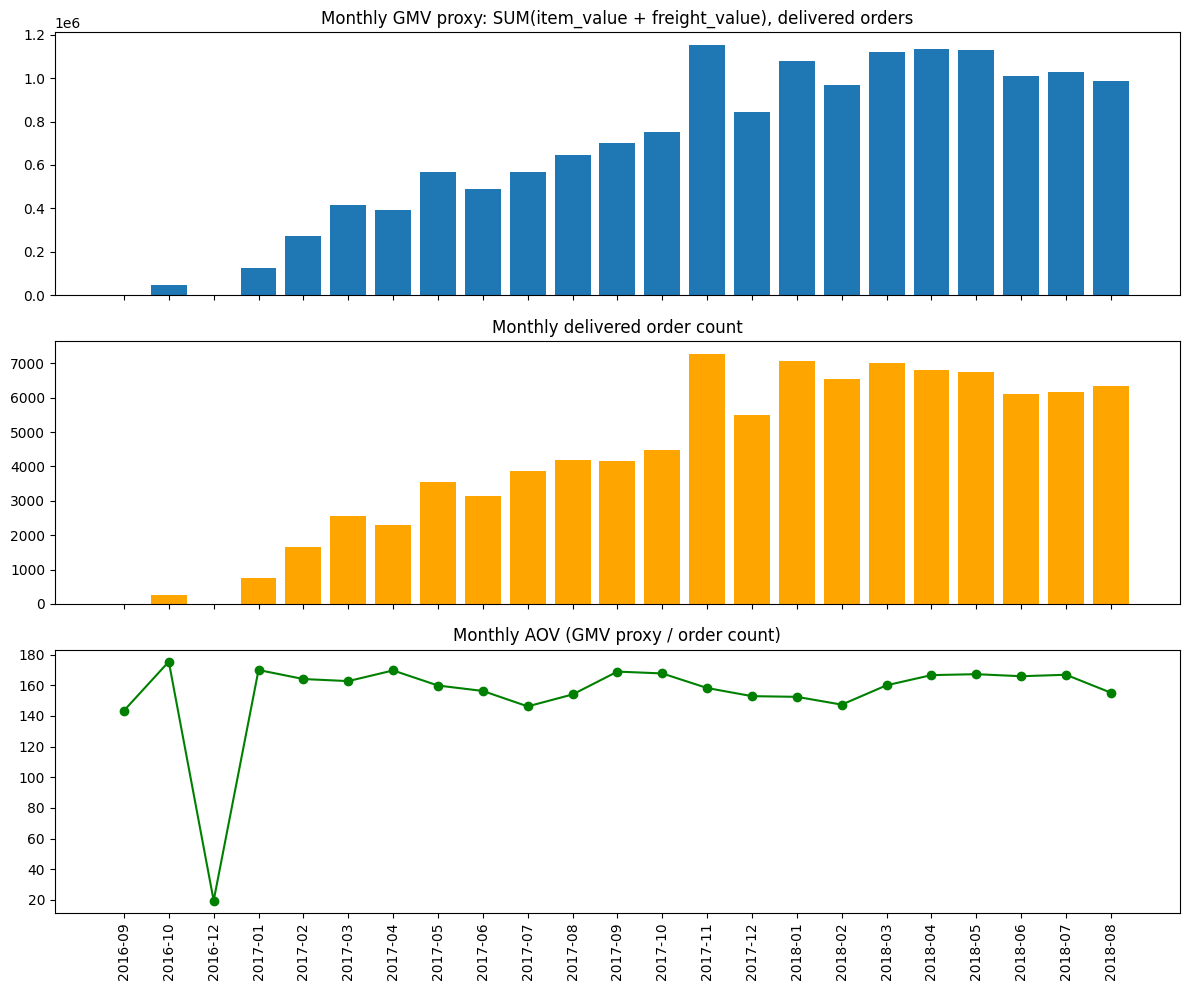


Extreme value check:
  min positive order value: 9.59 BRL
  max order value:          13664.08 BRL
  orders with zero/null item_plus_freight among delivered: 0


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].bar(monthly["month_str"], monthly["total_gmv_proxy"])
axes[0].set_title("Monthly GMV proxy: SUM(item_value + freight_value), delivered orders")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(monthly["month_str"], monthly["order_count"], color="orange")
axes[1].set_title("Monthly delivered order count")
axes[1].tick_params(axis="x", rotation=90)

axes[2].plot(monthly["month_str"], monthly["aov"], marker="o", color="green")
axes[2].set_title("Monthly AOV (GMV proxy / order count)")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print("\nExtreme value check:")
print(f"  min positive order value: {delivered_ts[delivered_ts['item_plus_freight']>0]['item_plus_freight'].min():.2f} BRL")
print(f"  max order value:          {delivered_ts['item_plus_freight'].max():.2f} BRL")
print(f"  orders with zero/null item_plus_freight among delivered: {(delivered_ts['item_plus_freight'].fillna(0) == 0).sum()}")

**Observed fact**: monthly delivered-order GMV proxy and order count both show a smooth, plausible growth curve from late 2016 (near-zero volume, consistent with the marketplace's early ramp-up) through mid-2018, with no negative totals, no missing months (after the initial ramp-up), and no implausible spikes. Monthly AOV stays within a narrow band (~146–176 BRL) across the entire window — no month is a wild outlier. No `delivered` order has a zero or null `item_plus_freight`. This supports `item_plus_freight` on `delivered` orders as a stable, well-behaved candidate metric.

## 9. Raw-data integrity check

Confirms that nothing in this notebook modified any raw CSV under `data/raw/olist/`.

In [25]:
hashes_after = {p.name: file_hash(p) for p in [orders_path, items_path, payments_path]}

for name in hashes_before:
    assert hashes_before[name] == hashes_after[name], f"raw file {name} was modified during this notebook run!"

print("ASSERTIONS PASSED: all raw CSV file hashes are unchanged before vs. after this notebook ran.")
for name, h in hashes_after.items():
    print(f"  {name}: {h}")

ASSERTIONS PASSED: all raw CSV file hashes are unchanged before vs. after this notebook ran.
  olist_orders_dataset.csv: 8bd60e55c1ca229d9f70b62f3e72f22c
  olist_order_items_dataset.csv: f4fa76976662e9cba0633f9e49ed2645
  olist_order_payments_dataset.csv: 75ce0c041d18e5f250c5cea9a8042944


## Summary of all assertions run in this notebook

1. Naive `order_items` x `order_payments` join inflates `SUM(price)` — demonstrated and asserted (Section 2).
2. Order-grain aggregates (`item_agg`, `pay_agg`) each have exactly one row per `order_id` — asserted (Section 3).
3. The 1:1 join of `orders` + `item_agg` + `pay_agg` preserves the `orders` row count exactly and remains keyed by `order_id` — asserted (Section 3).
4. All 8 known `order_status` values are present and none are excluded from the status breakdown — asserted (Section 5).
5. Raw CSV file hashes are identical before and after the notebook ran — asserted (Section 9).

Findings from this notebook are written up in `docs/FINANCIAL_RECONCILIATION.md`, including the final primary KPI recommendation and supporting metrics. No KPI YAML/contract is created here or there, per scope.